# Plot training metrics from `PlainFileLogger` (JSONL)

This notebook reads the JSON-lines logfile written when `wandb` is disabled (see `PlainFileLogger` in `src/file_logger.py`).

**What you need to do**
1. Set `LOGFILE_PATH` in the next cell to your logfile (e.g., `runs/logfile_<run_name>`).
2. Run the cells top-to-bottom to get clean metric curves.

In [29]:
from __future__ import annotations

import json
from pathlib import Path
from typing import Any

import pandas as pd

def find_repo_root(start: Path | None = None) -> Path:
    p = (start or Path.cwd()).resolve()
    for parent in [p, *p.parents]:
        if (parent / "src" / "train.py").exists():
            return parent
    return p

ROOT = find_repo_root()
RUNS_DIR = ROOT / "runs"

# Point this to your JSONL logfile (written by PlainFileLogger).
# If left as None, we auto-pick the newest `runs/logfile_*` file.
LOGFILE_PATH:  Path | None = Path("runs/logfile_energy_force_OM25_HCNOF_1M_h5_fm_cons_ef_hjb_wotv2_100326")

def pick_latest_logfile(runs_dir: Path) -> Path:
    candidates = sorted(runs_dir.glob("logfile_*"), key=lambda p: p.stat().st_mtime, reverse=True)
    if not candidates:
        raise FileNotFoundError(f"No logfile_* found under: {runs_dir}")
    return candidates[0]

if LOGFILE_PATH is None:
    LOGFILE_PATH = pick_latest_logfile(RUNS_DIR)
elif not LOGFILE_PATH.is_absolute():
    # Interpret relative paths as relative to repo root
    LOGFILE_PATH = (ROOT / LOGFILE_PATH).resolve()

assert LOGFILE_PATH.exists(), f"Logfile not found: {LOGFILE_PATH}"
print("Using logfile:", LOGFILE_PATH)

def _is_number(x: Any) -> bool:
    return isinstance(x, (int, float)) and x is not None

def load_jsonl(path: Path) -> list[dict[str, Any]]:
    records: list[dict[str, Any]] = []
    with path.open("r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            try:
                rec = json.loads(line)
            except json.JSONDecodeError:
                continue
            if isinstance(rec, dict):
                records.append(rec)
    return records

def metrics_dataframe(records: list[dict[str, Any]]) -> pd.DataFrame:
    rows: list[dict[str, Any]] = []
    for rec in records:
        if rec.get("type") != "metrics":
            continue
        step = rec.get("step")
        wall_time = rec.get("time")
        metrics = rec.get("metrics") or {}
        if not isinstance(metrics, dict):
            continue
        for k, v in metrics.items():
            if _is_number(v):
                rows.append({"step": step, "time": wall_time, "metric": str(k), "value": float(v)})
    df = pd.DataFrame(rows)
    if df.empty:
        return df
    df = df.dropna(subset=["step"]).copy()
    df["step"] = df["step"].astype(int)
    df["time"] = pd.to_datetime(df["time"], unit="s", origin="unix")
    return df.sort_values(["metric", "step"]).reset_index(drop=True)

records = load_jsonl(LOGFILE_PATH)
df = metrics_dataframe(records)
df.head()

Using logfile: /home/iwe67/PycharmProjects/DrugFlow/runs/logfile_energy_force_OM25_HCNOF_1M_h5_fm_cons_ef_hjb_wotv2_100326


,step,time,metric,value
0,49,2026-03-10 16:06:43.113231659,epoch,0.0
1,99,2026-03-10 16:07:49.697123766,epoch,0.0
2,149,2026-03-10 16:08:56.823617458,epoch,0.0
3,199,2026-03-10 16:10:04.117690563,epoch,0.0
4,249,2026-03-10 16:11:10.265306473,epoch,0.0


In [30]:
# Quick sanity checks / overview
print(f"Loaded {len(records):,} JSONL records")
print(f"Loaded {len(df):,} metric points")

if df.empty:
    raise RuntimeError("No metrics found. Is this the right logfile?")

metrics = sorted(df["metric"].unique().tolist())
print(f"Found {len(metrics)} unique metrics")
pd.Series(metrics).to_frame("metric").head(40)

Loaded 3,517 JSONL records
Loaded 16,796 metric points
Found 33 unique metrics


,metric
0,epoch
1,loss/train_epoch
2,loss/train_step
3,loss/val
4,loss_cfm/train_epoch
5,loss_cfm/train_step
6,loss_cfm/val
7,loss_consistency/train_epoch
8,loss_consistency/train_step
9,loss_consistency/val


In [31]:
import matplotlib.pyplot as plt
import numpy as np

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "legend.fontsize": 10,
})

def select_metrics(df: pd.DataFrame, *, prefix: str) -> list[str]:
    return sorted([m for m in df["metric"].unique().tolist() if m.startswith(prefix)])

def _pick_cmap(n: int):
    # tab20 is qualitative (good for many lines); turbo is a decent fallback for >20
    if n <= 10:
        return plt.get_cmap("tab10", n)
    if n <= 20:
        return plt.get_cmap("tab20", n)
    return plt.get_cmap("turbo", n)

def group_metrics_by_magnitude(
    df: pd.DataFrame,
    metric_names: list[str],
    *,
    bin_width: int = 1,
    quantile: float = 0.5,
    use_abs: bool = True,
    min_positive: float = 1e-12,
    ) -> dict[str, list[str]]:
    """Group metrics by order-of-magnitude of a robust scale estimate.

    We compute a per-metric scale as `quantile(|value|)` (default: median absolute value).
    Then we group by log10(scale) bins of width `bin_width` (default: 1 decade).

    Returns a dict mapping human-readable labels -> metric name list.
    """
    if not metric_names:
        return {}
    if bin_width < 1:
        raise ValueError("bin_width must be >= 1")
    if not (0.0 < quantile <= 1.0):
        raise ValueError("quantile must be in (0, 1]")

    scales: dict[str, float] = {}
    for m in metric_names:
        sub = df[df["metric"] == m]["value"]
        if sub.empty:
            continue
        vals = sub.to_numpy(dtype=float)
        if use_abs:
            vals = np.abs(vals)
        # Robust scale: ignore NaNs and compute the requested quantile
        vals = vals[np.isfinite(vals)]
        if vals.size == 0:
            continue
        scales[m] = float(np.quantile(vals, quantile))

    # Group by decade bins
    groups: dict[int, list[str]] = {}
    zeros: list[str] = []
    missing: list[str] = []

    for m in metric_names:
        if m not in scales:
            missing.append(m)
            continue
        s = scales[m]
        if not np.isfinite(s) or s <= 0.0:
            zeros.append(m)
            continue
        exp = int(np.floor(np.log10(max(s, min_positive))))
        bin_floor = (exp // bin_width) * bin_width
        groups.setdefault(bin_floor, []).append(m)

    out: dict[str, list[str]] = {}
    for bin_floor in sorted(groups.keys(), reverse=True):
        lo = bin_floor
        hi = bin_floor + bin_width - 1
        label = f"~1e{lo}" if lo == hi else f"~1e{lo}..1e{hi}"
        out[label] = sorted(groups[bin_floor])
    if zeros:
        out["~0"] = sorted(zeros)
    if missing:
        out["(missing)"] = sorted(missing)
    return out

def plot_metric_curves(
    df: pd.DataFrame,
    *,
    metric_names: list[str],
    title: str,
    smooth_window: int = 25,
    x: str = "step",
    figsize: tuple[float, float] = (10.5, 4.2),
    yscale: str = "linear",  # "linear" | "log" | "symlog"
    ylim: tuple[float, float] | None = None,
    legend: bool = True,
    alpha_raw: float = 0.16,
    lw_raw: float = 1.0,
    lw_smooth: float = 2.2,
    ) -> None:
    if not metric_names:
        print(f"[plot] No metrics for: {title}")
        return

    fig, ax = plt.subplots(figsize=figsize)
    cmap = _pick_cmap(len(metric_names))

    # If log scale is requested but data contains non-positive values, fall back to symlog.
    requested_yscale = (yscale or "linear").lower()
    if requested_yscale not in {"linear", "log", "symlog"}:
        raise ValueError(f"Invalid yscale={yscale!r}. Use 'linear', 'log', or 'symlog'.")

    global_min = None
    for metric in metric_names:
        sub = df[df["metric"] == metric]
        if sub.empty:
            continue
        mmin = float(sub["value"].min())
        global_min = mmin if global_min is None else min(global_min, mmin)

    effective_yscale = requested_yscale
    if requested_yscale == "log" and global_min is not None and global_min <= 0.0:
        effective_yscale = "symlog"
        print(f"[plot] '{title}': yscale='log' requested but min(value)={global_min:.3g} <= 0; using yscale='symlog'.")

    # Collect second-half y-values for auto ylim (computed before plotting)
    if ylim is None:
        all_xs: list[np.ndarray] = []
        for metric in metric_names:
            sub = df[df["metric"] == metric].sort_values(x)
            if not sub.empty:
                all_xs.append(sub[x].to_numpy())
        if all_xs:
            x_min = min(a.min() for a in all_xs)
            x_max = max(a.max() for a in all_xs)
            x_mid = x_min + (x_max - x_min) / 2.0
            second_half_vals: list[float] = []
            for metric in metric_names:
                sub = df[df["metric"] == metric].sort_values(x)
                if sub.empty:
                    continue
                mask = sub[x].to_numpy() >= x_mid
                ys_half = sub["value"].to_numpy()[mask]
                ys_half = ys_half[np.isfinite(ys_half)]
                second_half_vals.extend(ys_half.tolist())
            if second_half_vals:
                mean_half = float(np.mean(second_half_vals))
                std_half = float(np.std(second_half_vals))
                # Center ylim on the mean of the second half, ±3 std with a minimum margin
                margin = max(3.0 * std_half, abs(mean_half) * 0.05, 1e-8)
                ylim = (mean_half - margin, mean_half + margin)

    for i, metric in enumerate(metric_names):
        sub = df[df["metric"] == metric].sort_values(x)
        if sub.empty:
            continue
        xs = sub[x].to_numpy()
        ys = sub["value"].to_numpy()
        color = cmap(i)

        # Raw curve (faint)
        ax.plot(xs, ys, color=color, alpha=alpha_raw, linewidth=lw_raw)

        # Smoothed curve (bold) - same color as raw (avoids color duplication)
        if smooth_window and len(ys) >= 2:
            ys_smooth = (
                pd.Series(ys)
                .rolling(smooth_window, min_periods=max(2, smooth_window // 10))
                .mean()
                .to_numpy()
            )
            ax.plot(xs, ys_smooth, color=color, label=metric, linewidth=lw_smooth)
        else:
            ax.plot(xs, ys, color=color, label=metric, linewidth=lw_smooth)

    ax.set_title(title)
    ax.set_xlabel(x)
    ax.set_ylabel("value")
    ax.set_yscale(effective_yscale)
    if ylim is not None:
        ax.set_ylim(*ylim)
    if legend:
        ax.legend(loc="best", frameon=True, ncol=1)
    fig.tight_layout()
    plt.show()


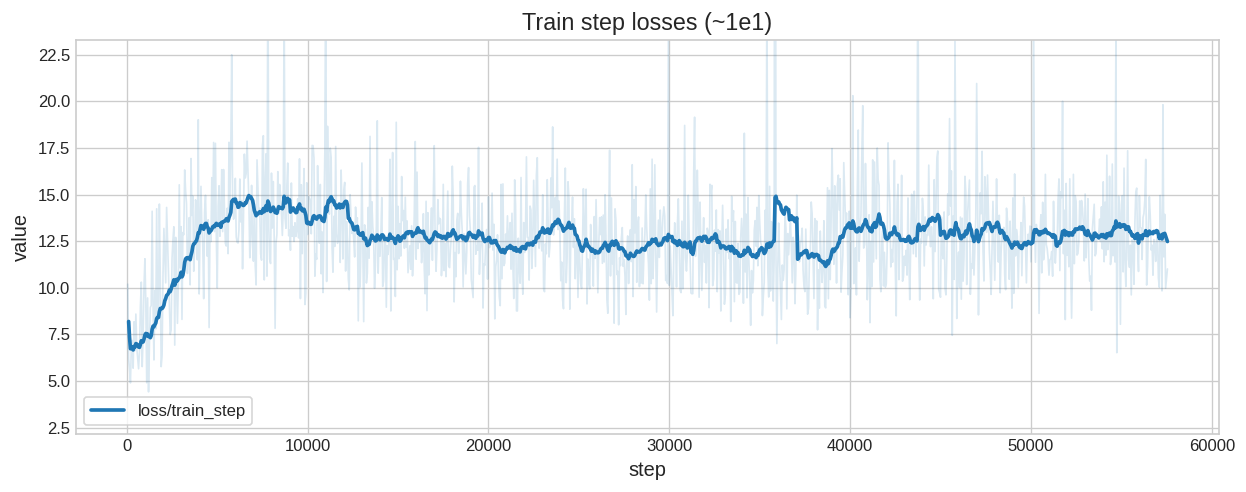

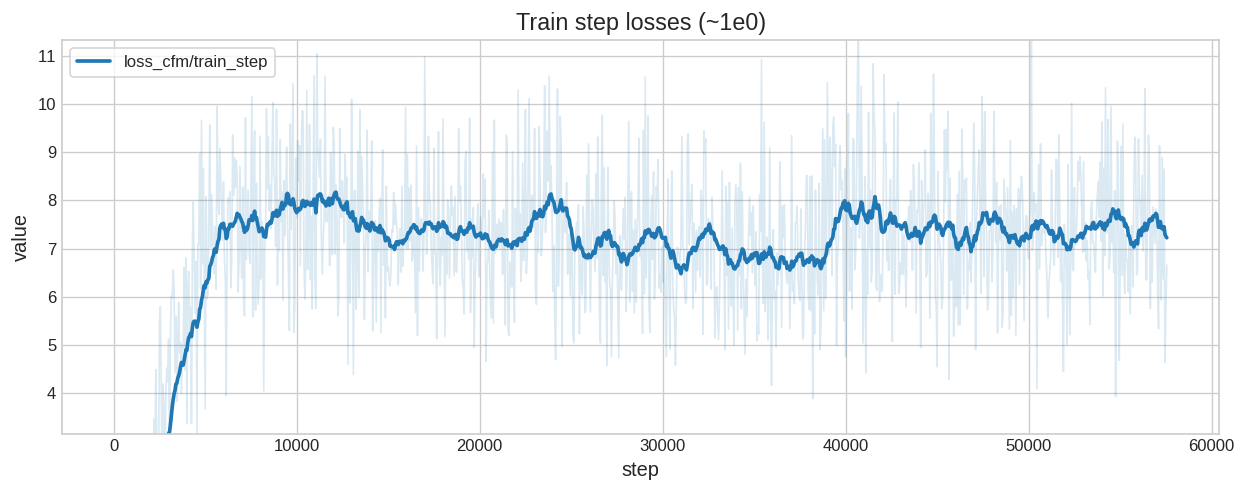

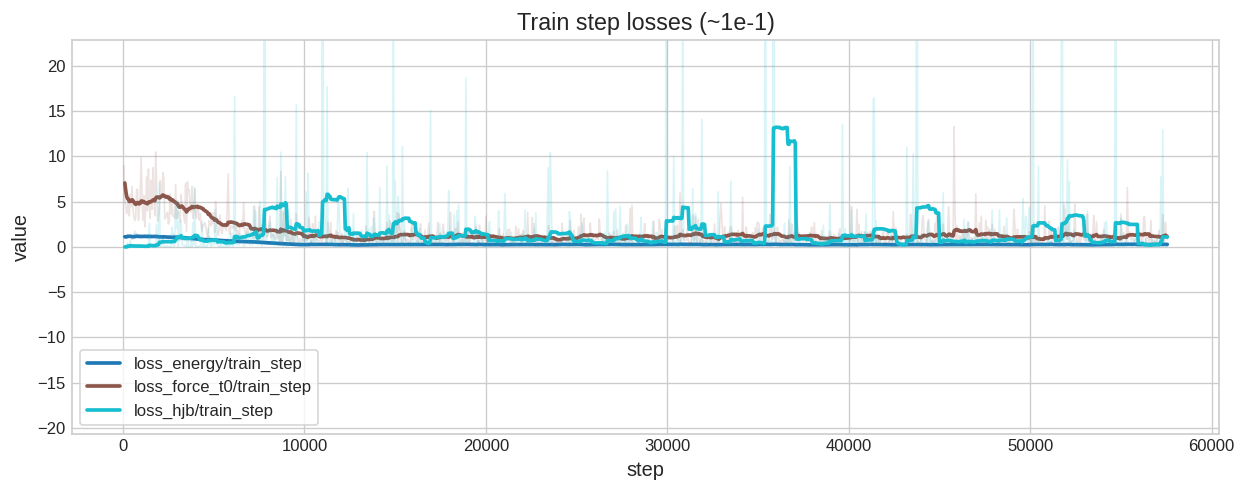

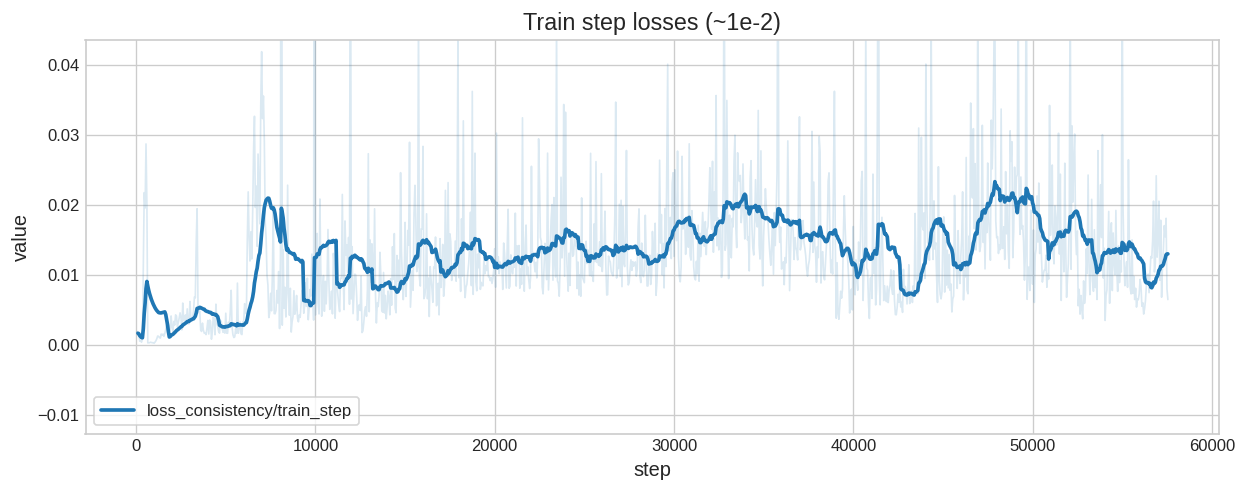

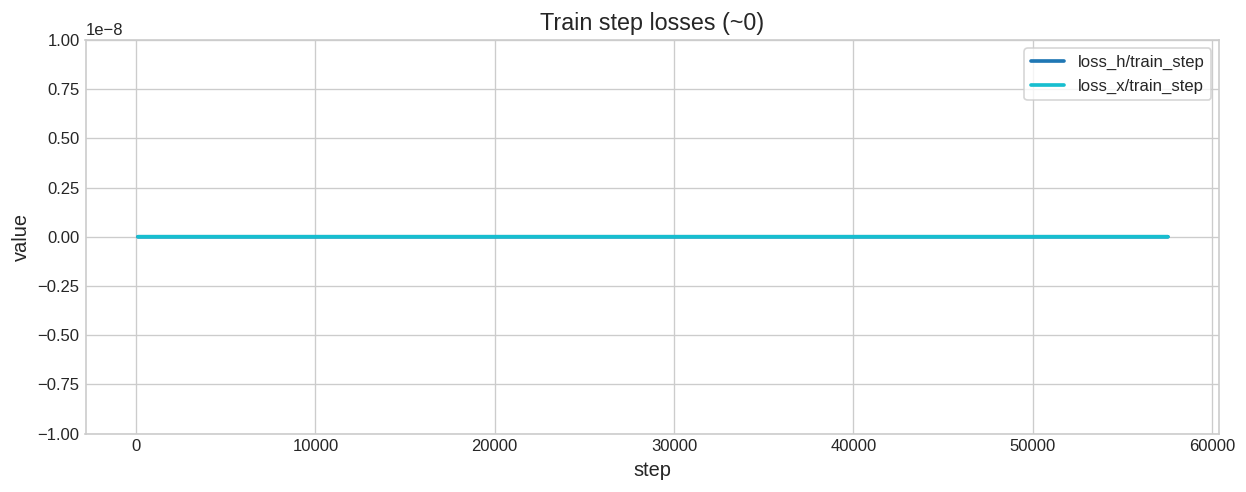

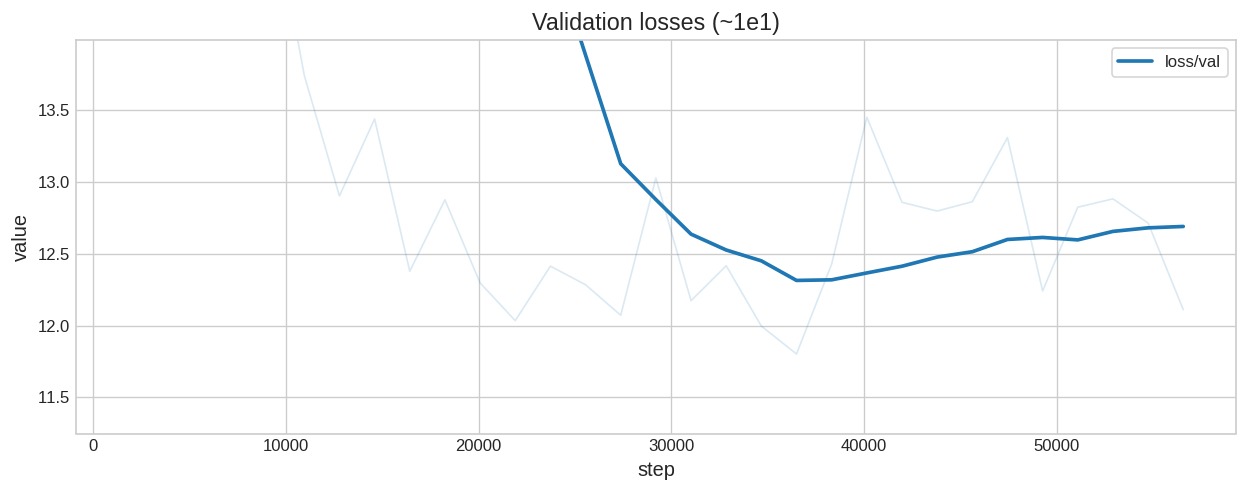

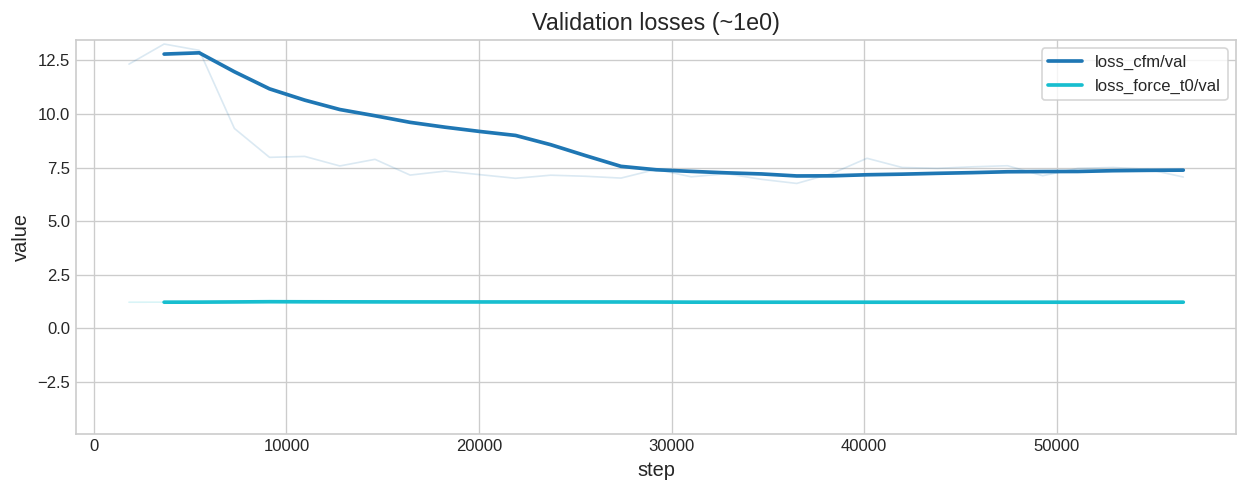

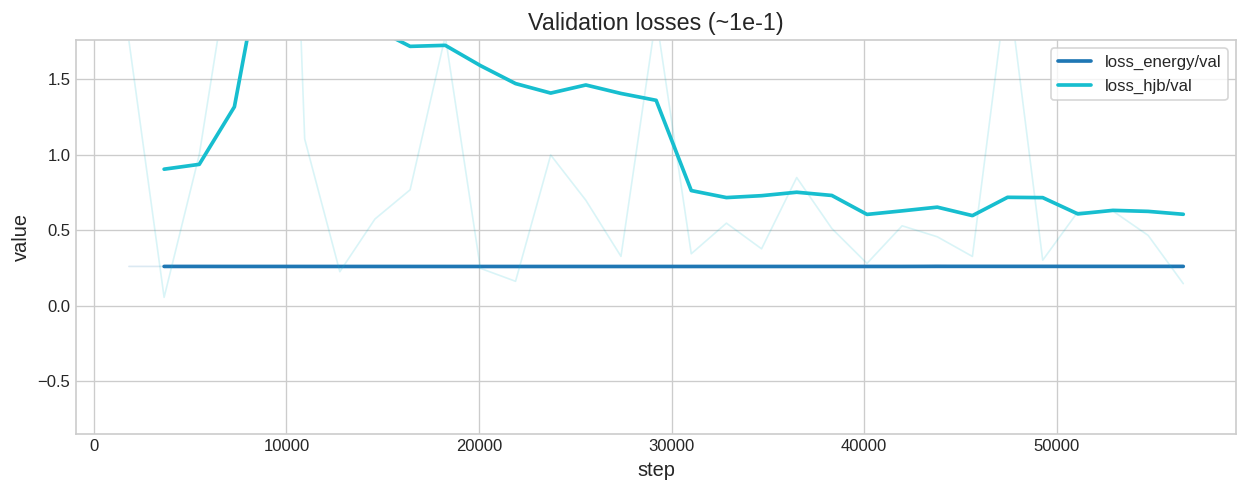

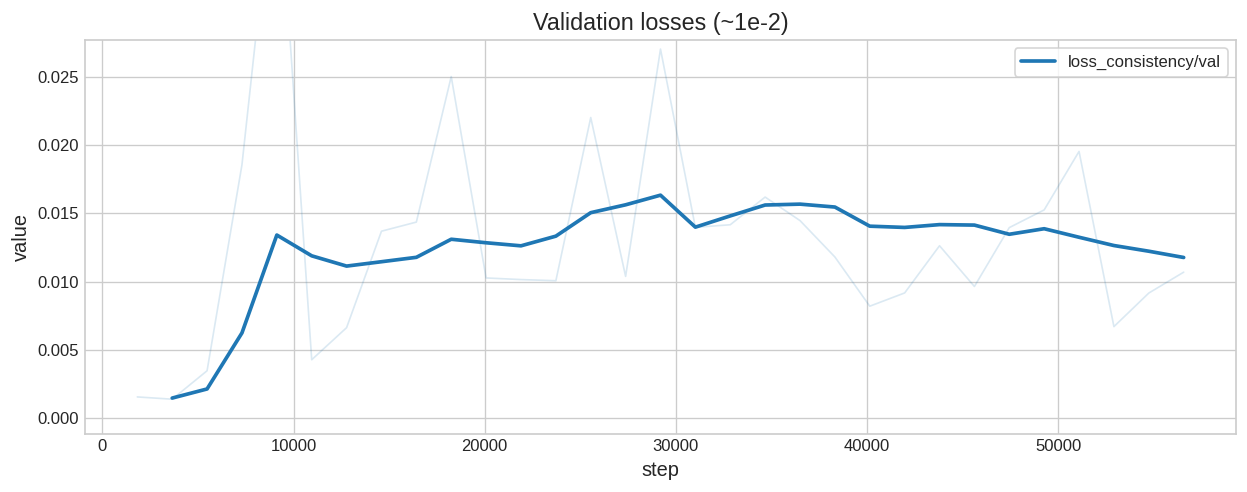

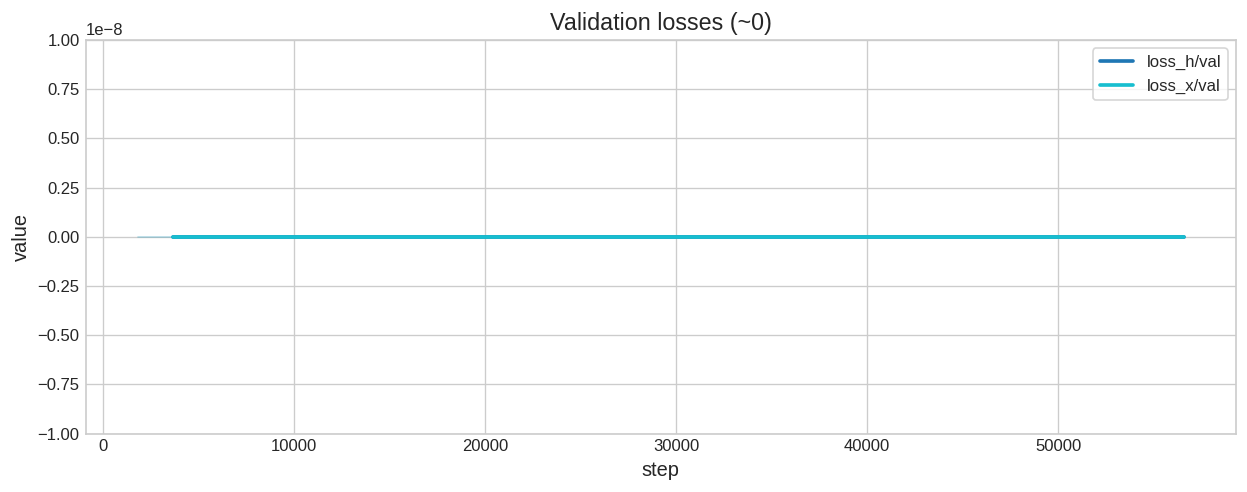

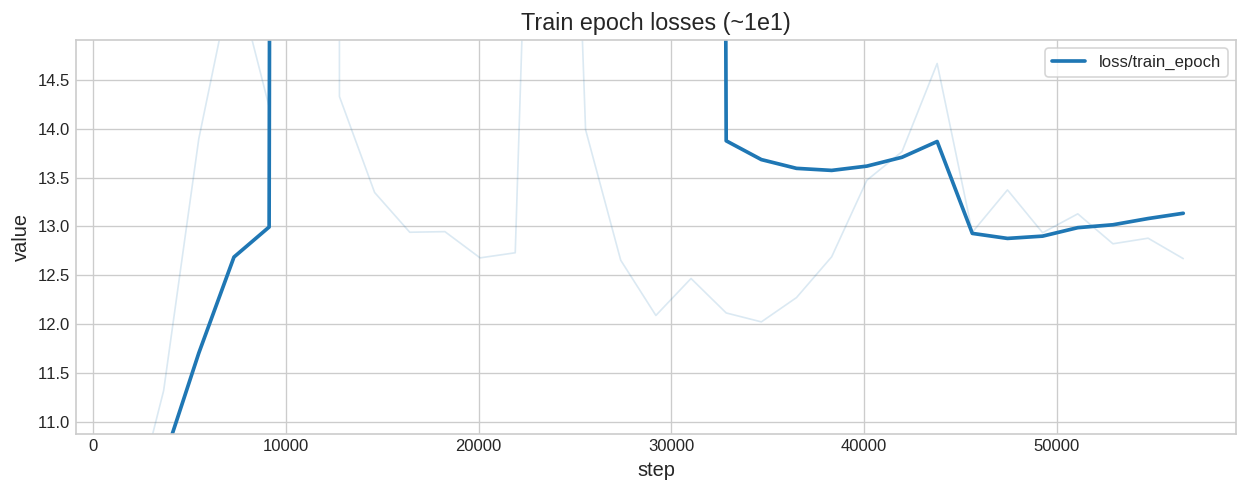

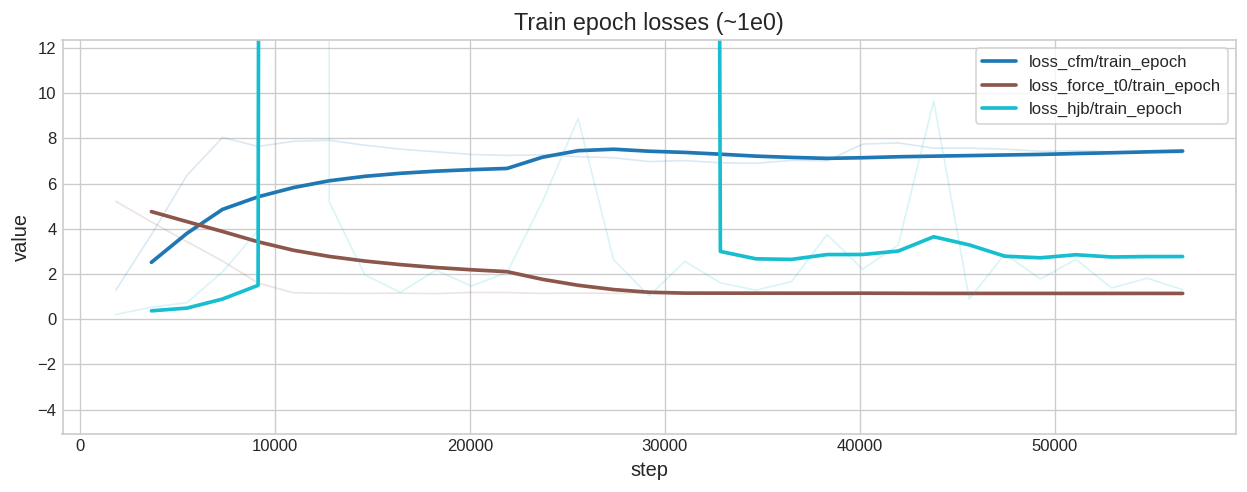

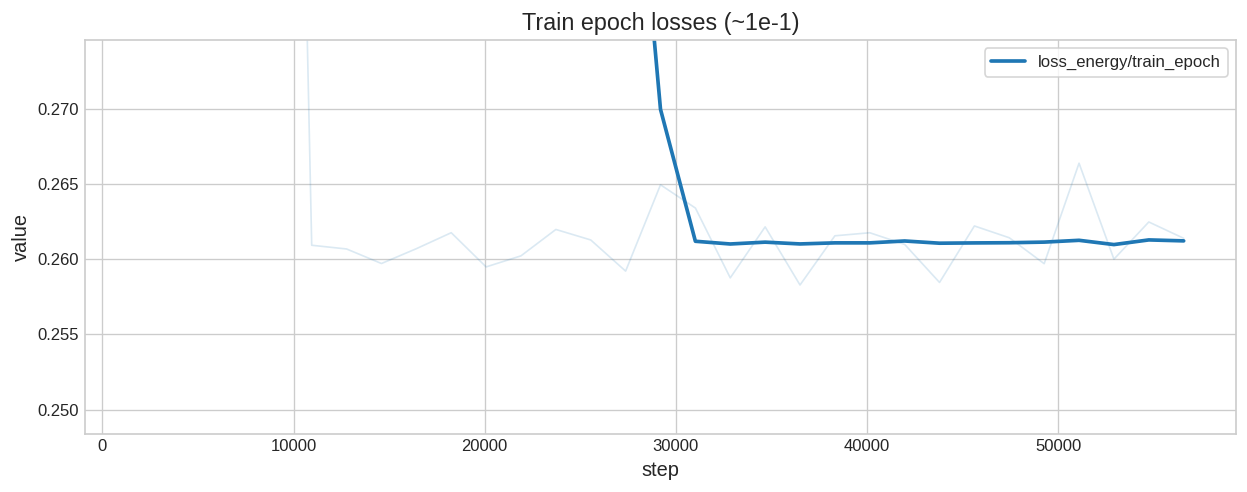

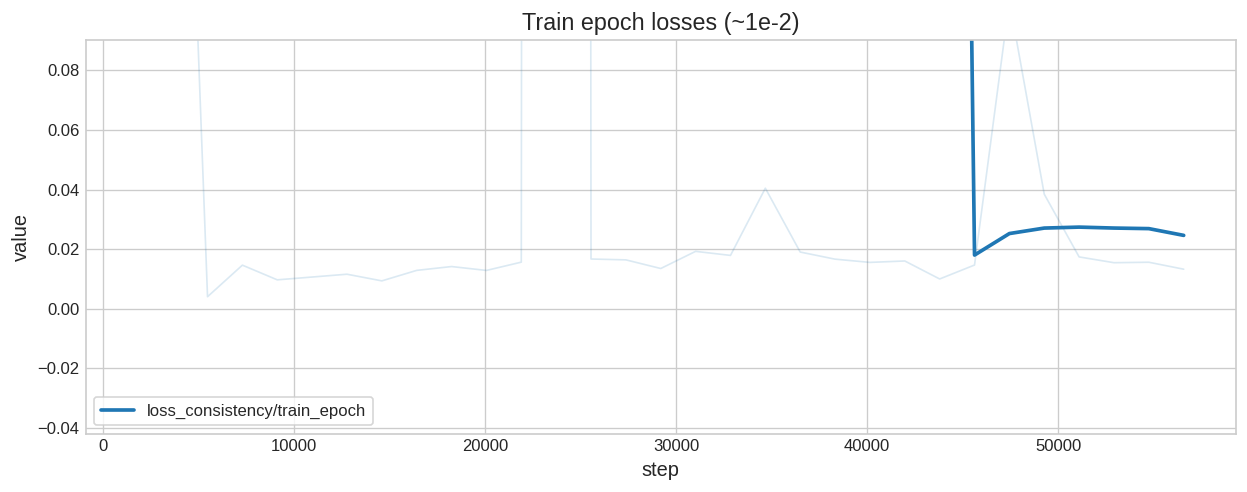

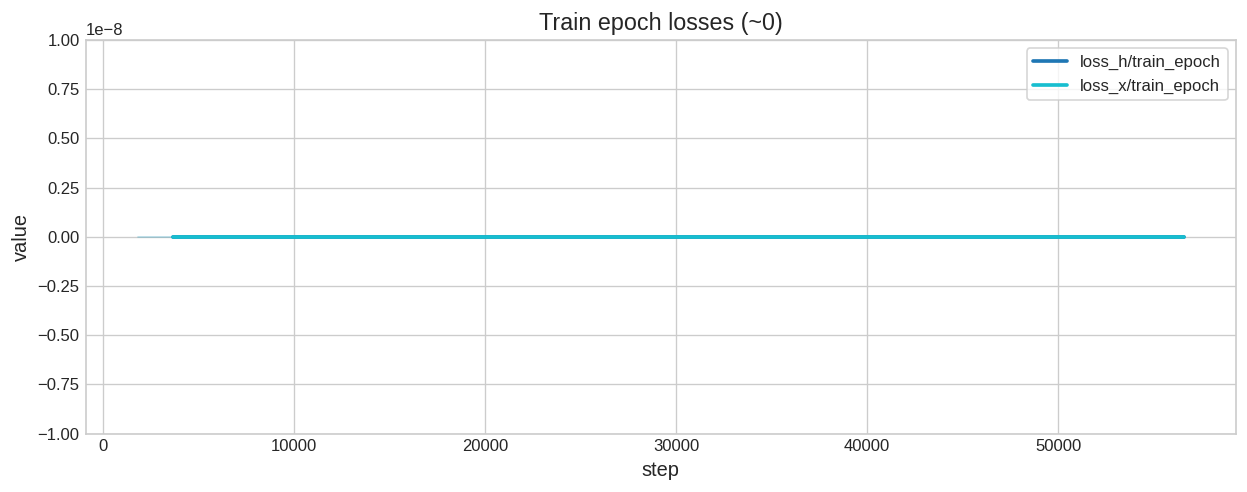

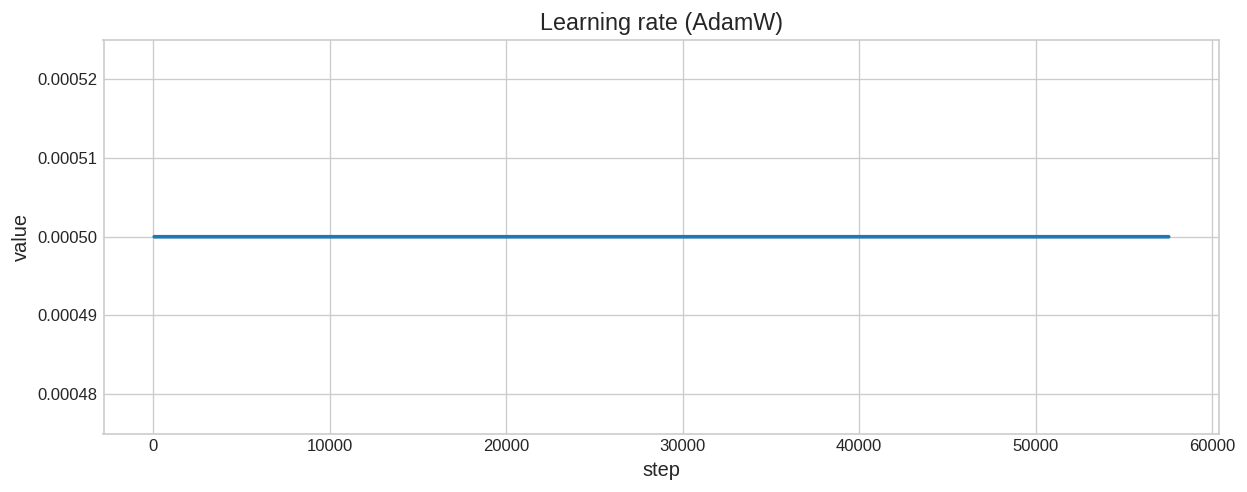

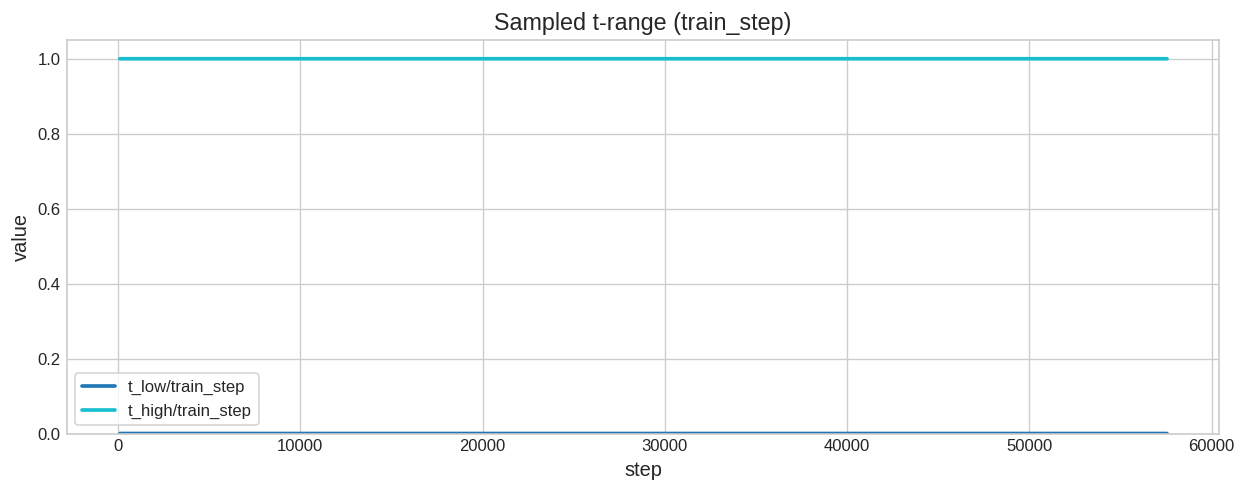

In [32]:
# ---- Main plots (edit to taste) ----
SMOOTH_WINDOW = 25  # in logged points (not epochs)

# For plots mixing losses with very different magnitudes, log scaling can help.
# Options: "linear" (default), "log" (positive-only), "symlog" (handles zeros/negatives).
LOSS_YSCALE = "linear"  # try: "log" or "symlog"

# Automatically group loss curves by magnitude (recommended).
GROUP_LOSSES_BY_MAGNITUDE = True
MAG_BIN_WIDTH = 1         # decades per group (1 groups by 1e-3 vs 1e-2 etc.)
MAG_QUANTILE = 0.5        # 0.5=median(|loss|); increase (e.g. 0.8) to reflect typical peaks

# Common groups (if present)
train_step_losses = [
    m for m in df["metric"].unique()
    if m.endswith("/train_step") and (m.startswith("loss") or m.startswith("loss_"))
].copy()
val_losses = [
    m for m in df["metric"].unique()
    if m.endswith("/val") and (m.startswith("loss") or m.startswith("loss_"))
].copy()
train_epoch_losses = [
    m for m in df["metric"].unique()
    if m.endswith("/train_epoch") and (m.startswith("loss") or m.startswith("loss_"))
].copy()

# Keep a stable, readable ordering
def _sort_key(name: str) -> tuple[int, str]:
    # Put total loss first if present
    if name.startswith("loss/"):
        return (0, name)
    if name.startswith("loss_"):
        return (1, name)
    return (2, name)

train_step_losses = sorted(train_step_losses, key=_sort_key)
val_losses = sorted(val_losses, key=_sort_key)
train_epoch_losses = sorted(train_epoch_losses, key=_sort_key)

def plot_losses_section(metric_names: list[str], *, title: str, smooth_window: int) -> None:
    if not metric_names:
        print(f"[plot] No metrics for: {title}")
        return

    if not GROUP_LOSSES_BY_MAGNITUDE:
        plot_metric_curves(
            df,
            metric_names=metric_names,
            title=title,
            smooth_window=smooth_window,
            yscale=LOSS_YSCALE,
        )
        return

    groups = group_metrics_by_magnitude(
        df,
        metric_names,
        bin_width=MAG_BIN_WIDTH,
        quantile=MAG_QUANTILE,
        use_abs=True,
    )
    for label, metrics_in_group in groups.items():
        # Skip empty / missing groups; keep "~0" if you want to inspect zeros
        if not metrics_in_group:
            continue
        plot_metric_curves(
            df,
            metric_names=metrics_in_group,
            title=f"{title} ({label})",
            smooth_window=smooth_window,
            yscale=LOSS_YSCALE,
        )

# Loss curves (grouped by magnitude if enabled)
plot_losses_section(train_step_losses, title="Train step losses", smooth_window=SMOOTH_WINDOW)
plot_losses_section(val_losses, title="Validation losses", smooth_window=max(5, SMOOTH_WINDOW // 2))
if train_epoch_losses:
    plot_losses_section(train_epoch_losses, title="Train epoch losses", smooth_window=max(3, SMOOTH_WINDOW // 2))

# Learning rate
if "lr-AdamW" in set(df["metric"].unique()):
    plot_metric_curves(
        df,
        metric_names=["lr-AdamW"],
        title="Learning rate (AdamW)",
        smooth_window=0,
        legend=False,
        yscale="linear",
    )

# Time-horizon schedule diagnostics (if logged)
t_metrics = [m for m in ["t_low/train_step", "t_high/train_step"] if m in set(df["metric"].unique())]
if t_metrics:
    plot_metric_curves(
        df,
        metric_names=t_metrics,
        title="Sampled t-range (train_step)",
        smooth_window=SMOOTH_WINDOW,
        ylim=(0.0, 1.05),
        yscale="linear",
    )